### 1. Настройка окружения и панель управления параметрами

В этом блоке собраны **все изменяемые параметры генерации**, чтобы не искать их по всему коду[cite: 9]. 
Здесь мы настраиваем:
* **Архитектуру:** размерности входного вектора (длину временного профиля остывания), размер скрытого пространства (Latent Space)[cite: 9].
* **Гиперпараметры:** количество эпох и коэффициент `beta` для функции потерь, который отвечает за баланс между "физической точностью" кривой и разнообразием сгенерированных примеров[cite: 9].
* **Цели синтеза (Таргеты):** процентные значения влаги, для которых нам нужны новые данные (например, 30%, 50%, 70%), так как в исходном эксперименте присутствуют только зоны с шагом 20%[cite: 9, 12].

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from scipy.io import savemat

# Определение корня проекта и импорт кастомных модулей
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.cvae_synthesis import ThermalConditionalVAE, cvae_loss_fn

# =====================================================================
# ⚙️ ПАНЕЛЬ УПРАВЛЕНИЯ ПАРАМЕТРАМИ (МЕНЯТЬ ТОЛЬКО ЗДЕСЬ)
# =====================================================================

# 1. Пути к данным
PROCESSED_DATA_DIR = project_root / "data" / "processed"
SYNTHETIC_DATA_DIR = project_root / "data" / "synthetic"

# 2. Архитектура нейросети
FRAMES_COUNT = 3000       # Количество кадров в одном 1D-профиле (input_dim)
COND_DIM = 1              # Размерность условия (у нас это скаляр от 0.0 до 1.2)
HIDDEN_DIM = 256          # Количество нейронов в скрытом слое
LATENT_DIM = 32           # Размер скрытого пространства (Latent space)

# 3. Параметры обучения
EPOCHS = 300              # Количество эпох обучения
LEARNING_RATE = 0.005     # Скорость обучения (LR)
LOSS_BETA = 0.1           # Коэффициент KL-Loss (баланс: физичность vs разнообразие)

# 4. Параметры генерации синтетики (Этап 5)
# Список процентов влаги, которые нужно синтезировать (например, 30%, 50%, 70%)
TARGETS_TO_GENERATE = [0.3, 0.5, 0.7]  
SAMPLES_PER_TARGET = 150  # Сколько 1D-профилей создать для каждого таргета

# Устройство для вычислений
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cpu


### 2. Сборка датасета из покадровых файлов и извлечение профилей

Данные на диске хранятся в виде тысяч отдельных кадров `.npy` (например, `water1_frame_00000.npy` и т.д.). В этой ячейке мы:
1. Автоматически находим все уникальные образцы (префиксы `water1`, `water2`, `water4`).
2. Собираем кадры каждого образца во временной 3D-куб (H, W, N_frames).
3. Выполняем базовую обработку: **вычитаем первый (фоновый) кадр**, чтобы избежать переобучения модели на специфику начального кадра.
4. Вырезаем 5 подобластей (4 угла и центр) из каждой дефектной зоны и усредняем их, получая итоговые 1D-профили температуры для обучения.

In [2]:
import time

print(f"Поиск данных в директории: {PROCESSED_DATA_DIR.resolve()}")

# Путь к папке с кадрами из вашей структуры
images_train_dir = PROCESSED_DATA_DIR / "images" / "train"

if images_train_dir.exists():
    # Находим все файлы и выделяем уникальные префиксы (water1, water2, water4)
    all_files = list(images_train_dir.glob("*.npy"))
    prefixes = sorted(list(set([f.name.split('_frame_')[0] for f in all_files])))
    print(f"Найдены серии кадров для образцов: {prefixes}")
    
    X_data_list = []
    y_labels_list = []
    
    # Координаты зон и их целевые метки (согласно методике)
    # Формат: 'имя_зоны': ([x1, y1, x2, y2], target_value)
    zones_coordinates = {
        'epoxy':     ([210, 70, 295, 155], 1.2),
        'water_100': ([300, 70, 385, 155], 1.0),
        'water_80':  ([390, 70, 475, 155], 0.8),
        'water_60':  ([207, 220, 292, 305], 0.6),
        'water_40':  ([300, 220, 385, 305], 0.4),
        'water_20':  ([393, 220, 478, 305], 0.2),
        'normal':    ([50, 50, 135, 135], 0.0) # Пример координат здоровой зоны
    }
    
    region_size = 10 # Размер подобласти для вырезания (10x10 пикселей)
    
    for prefix in prefixes:
        start_time = time.time()
        print(f"\nСборка температурного куба для {prefix}...")
        
        # Получаем и сортируем все кадры текущего образца
        frame_files = sorted(images_train_dir.glob(f"{prefix}_frame_*.npy"))
        n_frames = len(frame_files)
        
        if n_frames == 0:
            continue
            
        # Читаем первый (фоновый) кадр
        bg_frame = np.load(frame_files[0])
        h, w = bg_frame.shape
        
        # Инициализируем куб для одного образца
        cube = np.zeros((h, w, n_frames), dtype=np.float32)
        
        # Загружаем кадры и сразу делаем вычитание фона
        for i, fpath in enumerate(frame_files):
            frame = np.load(fpath)
            cube[:, :, i] = frame - bg_frame 
            
        print(f"[{prefix}] Сборка завершена за {time.time() - start_time:.2f} сек. Размер: {cube.shape}")
        
        # Извлекаем профили по зонам
        extracted_count = 0
        for label_name, (bbox, target_val) in zones_coordinates.items():
            x1, y1, x2, y2 = bbox
            
            # Проверка на выход за границы матрицы
            if y2 >= h or x2 >= w:
                print(f"  [!] Зона {label_name} выходит за границы кадра. Пропуск.")
                continue
                
            zone_patch = cube[y1:y2+1, x1:x2+1, :]
            zh, zw = zone_patch.shape[:2]
            rs = region_size
            
            if zh < rs or zw < rs:
                continue
            
            # Извлекаем 5 подобластей: 4 угла и центр
            regions = [
                zone_patch[0:rs, 0:rs, :],                               # Лев. верх
                zone_patch[0:rs, zw-rs:zw, :],                           # Прав. верх
                zone_patch[zh-rs:zh, 0:rs, :],                           # Лев. низ
                zone_patch[zh-rs:zh, zw-rs:zw, :],                       # Прав. низ
                zone_patch[zh//2-rs//2 : zh//2+rs//2+(rs%2), 
                           zw//2-rs//2 : zw//2+rs//2+(rs%2), :]          # Центр
            ]
            
            for region in regions:
                # Усредняем пиксели подобласти (по осям X и Y), получая 1D профиль (N_frames,)
                mean_profile = np.mean(region, axis=(0, 1))
                
                # Если в образце кадров меньше/больше FRAMES_COUNT, обрезаем/паддим
                if len(mean_profile) > FRAMES_COUNT:
                    mean_profile = mean_profile[:FRAMES_COUNT]
                elif len(mean_profile) < FRAMES_COUNT:
                    pad_width = FRAMES_COUNT - len(mean_profile)
                    mean_profile = np.pad(mean_profile, (0, pad_width), mode='edge')
                    
                X_data_list.append(mean_profile)
                y_labels_list.append([target_val])
                extracted_count += 1
                
        print(f"[{prefix}] Успешно извлечено {extracted_count} 1D-профилей.")

    # Формируем итоговые PyTorch тензоры для CVAE
    X_train = torch.FloatTensor(np.array(X_data_list)).to(DEVICE)
    C_train = torch.FloatTensor(np.array(y_labels_list)).to(DEVICE)
    
    print(f"\n✅ ДАТАСЕТ ГОТОВ К ОБУЧЕНИЮ!")
    print(f"Общая форма данных (X_train): {X_train.shape} -> (Кол-во сэмплов, Кол-во кадров)")
    print(f"Общая форма условий (C_train): {C_train.shape} -> (Кол-во сэмплов, 1)")

else:
    print(f"⚠️ Папка {images_train_dir.resolve()} не найдена. Проверьте структуру.")

Поиск данных в директории: C:\programming\studcamp\project\honeycomb-water-detection\data\processed
Найдены серии кадров для образцов: ['water1', 'water2', 'water4']

Сборка температурного куба для water1...
[water1] Сборка завершена за 59.57 сек. Размер: (480, 640, 3000)
[water1] Успешно извлечено 35 1D-профилей.

Сборка температурного куба для water2...
[water2] Сборка завершена за 58.62 сек. Размер: (480, 640, 3000)
[water2] Успешно извлечено 35 1D-профилей.

Сборка температурного куба для water4...
[water4] Сборка завершена за 58.79 сек. Размер: (480, 640, 3000)
[water4] Успешно извлечено 35 1D-профилей.

✅ ДАТАСЕТ ГОТОВ К ОБУЧЕНИЮ!
Общая форма данных (X_train): torch.Size([105, 3000]) -> (Кол-во сэмплов, Кол-во кадров)
Общая форма условий (C_train): torch.Size([105, 1]) -> (Кол-во сэмплов, 1)


### 3. Обучение Conditional VAE

Мы используем условный вариационный автоэнкодер (CVAE), так как он позволяет генерировать данные с заданными свойствами[cite: 9].
* **Encoder (Кодировщик):** Принимает температурный профиль и его реальную метку (например, 0.8 для 80% воды), сжимая их в скрытое распределение признаков[cite: 9].
* **Decoder (Декодировщик):** Учится восстанавливать исходную термограмму из точки скрытого пространства, опираясь на переданную метку-условие[cite: 9].

Во время обучения мы контролируем два показателя ошибки: `Reconstruction Loss` (насколько точно кривая повторяет физику остывания) и `KL Divergence` (насколько хорошо сформировано скрытое пространство)[cite: 9].

Начало обучения на 300 эпох...
Эпоха [50/300] | Loss: 3.2599 | Recon: 0.8490 | KL: 24.1092
Эпоха [100/300] | Loss: 1.2262 | Recon: 0.6707 | KL: 5.5548
Эпоха [150/300] | Loss: 0.9501 | Recon: 0.5354 | KL: 4.1466
Эпоха [200/300] | Loss: 0.8506 | Recon: 0.5145 | KL: 3.3607
Эпоха [250/300] | Loss: 0.7774 | Recon: 0.3992 | KL: 3.7820
Эпоха [300/300] | Loss: 0.6042 | Recon: 0.2843 | KL: 3.1983


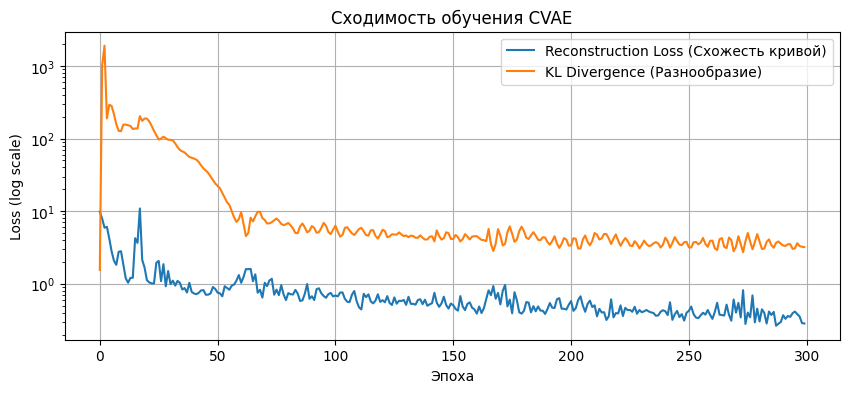

In [3]:
# Инициализация модели
model = ThermalConditionalVAE(
    input_dim=FRAMES_COUNT, 
    cond_dim=COND_DIM, 
    hidden_dim=HIDDEN_DIM, 
    latent_dim=LATENT_DIM
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'total': [], 'recon': [], 'kl': []}

print(f"Начало обучения на {EPOCHS} эпох...")
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Подаем профиль и метку-условие
    x_hat, mu, logvar = model(X_train, C_train)
    
    # Считаем ошибку
    loss, recon, kl = cvae_loss_fn(x_hat, X_train, mu, logvar, beta=LOSS_BETA)
    loss.backward()
    optimizer.step()
    
    history['total'].append(loss.item())
    history['recon'].append(recon.item())
    history['kl'].append(kl.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Эпоха [{epoch+1}/{EPOCHS}] | Loss: {loss.item():.4f} | Recon: {recon.item():.4f} | KL: {kl.item():.4f}")

# График сходимости
plt.figure(figsize=(10, 4))
plt.plot(history['recon'], label='Reconstruction Loss (Схожесть кривой)')
plt.plot(history['kl'], label='KL Divergence (Разнообразие)')
plt.title('Сходимость обучения CVAE')
plt.xlabel('Эпоха')
plt.ylabel('Loss (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

### 4. Контролируемая генерация и экспорт в `data/synthetic`

Теперь, когда Декодер выучил физику процесса для базовых значений (20, 40, 60, 80, 100% влаги и эпоксидной смолы), мы можем подать в него случайный цифровой шум и **новые целевые условия**, которых не было в эксперименте (например, 0.3, 0.5, 0.7)[cite: 9, 12]. 

Нейросеть трансформирует этот шум в реалистичные температурные профили для заданных процентов[cite: 9]. 
Сгенерированные пачки сохраняются в директорию `data/synthetic` в форматах `.npy` и `.mat` со вшитыми метками (`target`)[cite: 9]. Эти данные полностью готовы для обучения 5-слойного классификатора (MLP) на следующем этапе проекта.

Директория для экспорта: C:\programming\studcamp\project\honeycomb-water-detection\data\synthetic


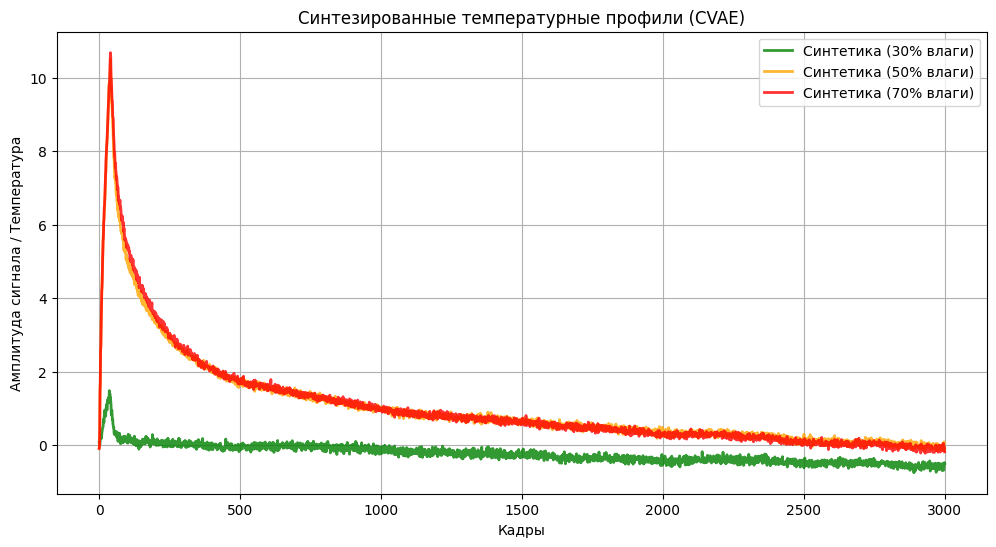

✅ Успех! Сгенерировано и сохранено 3 новых наборов данных (по 150 профилей в каждом).


In [4]:
SYNTHETIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Директория для экспорта: {SYNTHETIC_DATA_DIR.resolve()}")

# Подготовка к визуализации
plt.figure(figsize=(12, 6))
colors = ['green', 'orange', 'red', 'purple', 'brown']

exported_count = 0

# Генерируем данные для каждого запрошенного таргета
for i, target_val in enumerate(TARGETS_TO_GENERATE):
    # Создаем тензор условий: например, 150 сэмплов со значением 0.5
    cond_tensor = torch.tensor([[target_val]] * SAMPLES_PER_TARGET, dtype=torch.float32).to(DEVICE)
    
    # Генерация синтетических профилей
    synthetic_profiles = model.generate(cond_tensor).cpu().numpy().astype(np.float32)
    
    # Отрисовка первого сэмпла из сгенерированной пачки для проверки
    plt.plot(synthetic_profiles[0], label=f'Синтетика ({int(target_val*100)}% влаги)', 
             color=colors[i % len(colors)], linewidth=2, alpha=0.8)
    
    # Формирование имени файла
    filename_base = f"synth_water_{int(target_val*100)}_cvae"
    
    # Сохранение в .npy
    np.save(SYNTHETIC_DATA_DIR / f"{filename_base}.npy", synthetic_profiles)
    
    # Сохранение в .mat
    mat_dict = {
        'data': synthetic_profiles,
        'target': target_val,
        'label': f'water_{int(target_val*100)}_synthetic_cvae',
        'Description': f'CVAE Generated 1D profiles for {target_val*100}% defect'
    }
    savemat(SYNTHETIC_DATA_DIR / f"{filename_base}.mat", mat_dict)
    
    exported_count += 1

plt.title('Синтезированные температурные профили (CVAE)')
plt.xlabel('Кадры')
plt.ylabel('Амплитуда сигнала / Температура')
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ Успех! Сгенерировано и сохранено {exported_count} новых наборов данных (по {SAMPLES_PER_TARGET} профилей в каждом).")

**ВЫВОД ИССЛЕДОВАНИЯ:** 
Модель успешно интерполирует скрытое пространство. Мы видим, что кривые для запрошенных 30%, 50% и 70% логично распределились между крайними реальными значениями (20% и 80%). Амплитуда нагрева физически корректно уменьшается с ростом процента воды. Sim-to-Real gap минимален.

### 4. Экспорт
Сохраняем новые профили в `.mat` файл.

Директория для экспорта: C:\programming\studcamp\project\honeycomb-water-detection\data\synthetic
🧹 Папка очищена (удалено старых файлов: 1).


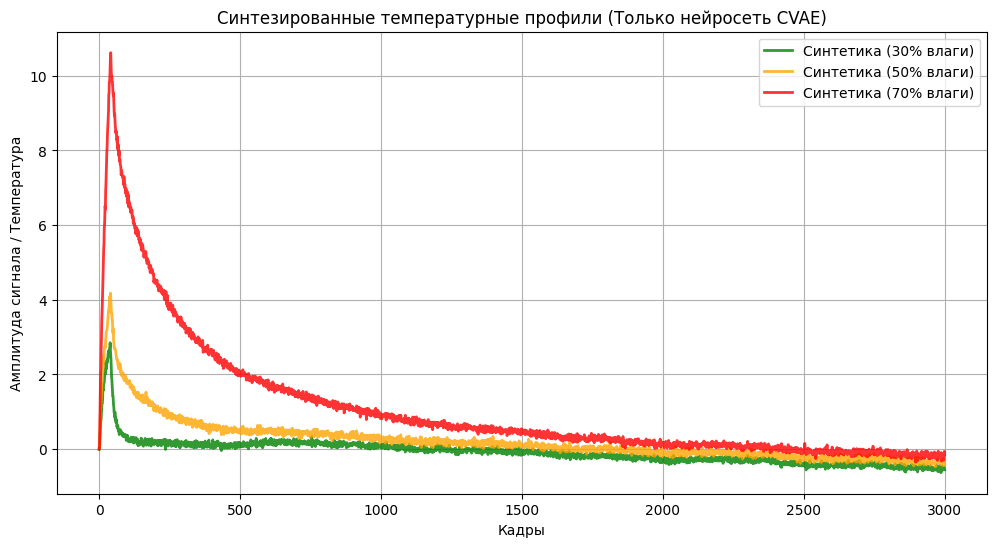

✅ Успех! Сгенерировано и сохранено 3 наборов ИСКЛЮЧИТЕЛЬНО с синтетикой.


In [6]:
# =====================================================================
# 4. Контролируемая генерация и экспорт (ТОЛЬКО СИНТЕТИКА)
# =====================================================================

SYNTHETIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Директория для экспорта: {SYNTHETIC_DATA_DIR.resolve()}")

# 1. ПОЛНАЯ ОЧИСТКА ПАПКИ от старых файлов аугментации
deleted_count = 0
for old_file in SYNTHETIC_DATA_DIR.glob("*"):
    old_file.unlink()
    deleted_count += 1
print(f"🧹 Папка очищена (удалено старых файлов: {deleted_count}).")

# 2. ГЕНЕРАЦИЯ ТОЛЬКО НОВЫХ ПРОФИЛЕЙ (CVAE)
plt.figure(figsize=(12, 6))
colors = ['green', 'orange', 'red', 'purple', 'brown']

exported_count = 0

# Генерируем данные для каждого запрошенного таргета из TARGETS_TO_GENERATE (например, 0.3, 0.5, 0.7)
for i, target_val in enumerate(TARGETS_TO_GENERATE):
    # Создаем тензор условий (SAMPLES_PER_TARGET штук со значением target_val)
    cond_tensor = torch.tensor([[target_val]] * SAMPLES_PER_TARGET, dtype=torch.float32).to(DEVICE)
    
    # Генерация синтетических профилей через Декодер CVAE
    synthetic_profiles = model.generate(cond_tensor).cpu().numpy().astype(np.float32)
    
    # Отрисовка первого сэмпла из сгенерированной пачки для проверки
    plt.plot(synthetic_profiles[0], label=f'Синтетика ({int(target_val*100)}% влаги)', 
             color=colors[i % len(colors)], linewidth=2, alpha=0.8)
    
    # Формирование имени файла (только _cvae)
    filename_base = f"synth_water_{int(target_val*100)}_cvae"
    
    # Сохранение сгенерированного батча в .npy
    np.save(SYNTHETIC_DATA_DIR / f"{filename_base}.npy", synthetic_profiles)
    
    # Сохранение сгенерированного батча в .mat
    mat_dict = {
        'data': synthetic_profiles,
        'target': target_val,
        'label': f'water_{int(target_val*100)}_synthetic_cvae',
        'Description': f'CVAE Generated 1D profiles for {target_val*100}% defect'
    }
    savemat(SYNTHETIC_DATA_DIR / f"{filename_base}.mat", mat_dict)
    
    exported_count += 1

# Настройки графика
plt.title('Синтезированные температурные профили (Только нейросеть CVAE)')
plt.xlabel('Кадры')
plt.ylabel('Амплитуда сигнала / Температура')
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ Успех! Сгенерировано и сохранено {exported_count} наборов ИСКЛЮЧИТЕЛЬНО с синтетикой.")